Week 3: Data Preprocessing
This notebook takes the filtered data from the 01_exploratory.ipynb file and focuses on preparing it for modeling, inclusing handling missing values, encoding categorical variables, and splitting the data into training and testing sets. 

In [59]:
from pathlib import Path
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [60]:
path_dir = Path("raw")
files = sorted(path_dir.glob("CRMLSSold*.csv"))
train_files = files[:-1]
test_file = files[-1]

train_list = [pd.read_csv(file, low_memory=False) for file in train_files]
df = pd.concat(train_list, ignore_index=True)

test_df = pd.read_csv(test_file, low_memory=False)

print(f"Training Period: {train_files[0].name} to {train_files[-1].name}") 
print(f"Test file: {test_file.name}")

print("The combined shape of Train DataFrame is:", df.shape)
print("Test shape:", test_df.shape)


Training Period: CRMLSSold202502.csv to CRMLSSold202607.csv
Test file: CRMLSSold202608.csv
The combined shape of Train DataFrame is: (400050, 80)
Test shape: (23131, 79)


In [61]:
df_scoped = df[
        (df['PropertyType'] == 'Residential') & 
        (df['PropertySubType'] == 'SingleFamilyResidence')].copy()
print("The shape of scoped DataFrame is:", df_scoped.shape)


The shape of scoped DataFrame is: (201413, 80)


In [62]:
# Determine the percentage of null values for each feature.
null_rates = (df_scoped.isnull().mean()*100).round(2)
print(null_rates[null_rates > 0].sort_values(ascending=False))

TaxYear                   100.00
BusinessType              100.00
FireplacesTotal           100.00
AboveGradeFinishedArea    100.00
TaxAnnualAmount           100.00
                           ...  
ListAgentFullName           0.03
ListAgentAOR                0.02
BathroomsTotalInteger       0.01
ListAgentLastName           0.01
PurchaseContractDate        0.01
Length: 62, dtype: float64


Checks:
1.  Check all numerical and categorical features for zero and missing values
2.  Check for duplicates across entire row

In [63]:
# Check for zero and missing values
num_feat = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "ClosePrice", 
            "Latitude", "Longitude","LotSizeSquareFeet", "YearBuilt",
            "Stories", "GarageSpaces"]

cat_feat = ["PostalCode", "City"]

features = num_feat + cat_feat

for col in num_feat:
    if col in df_scoped.columns:
        df_scoped[col] = pd.to_numeric(df_scoped[col], errors='coerce')

results=[]
for col in features:
    if col in df_scoped.columns:
        results.append({
            "Columns": col,
            "Zero Count": (df_scoped[col] == 0).sum(),
            "Null Count": df_scoped[col].isnull().sum()
        }) 
summary = pd.DataFrame(results)
print(summary.to_string(index=False))
print("Total Zero Count:", summary["Zero Count"].sum())
print("Total Null count:", summary["Null Count"].sum())


              Columns  Zero Count  Null Count
           LivingArea          91         110
        BedroomsTotal         125           0
BathroomsTotalInteger         100          19
           ClosePrice           1           0
             Latitude          23         513
            Longitude          23         513
    LotSizeSquareFeet         116        3511
            YearBuilt           0         139
              Stories           0       21289
         GarageSpaces       15805        7907
           PostalCode           0           3
                 City           0          73
Total Zero Count: 16284
Total Null count: 34077


Handling Missing Values
1. Null GarageSpaces probably means no Garage so fill it with 0.
2. Drop zero and missing values. 

In [64]:
df_model = df_scoped[features].copy()
before = len(df_model)

# Drop ClosePrice and LivingArea 0 and less
df_model = df_model[
            (df_model["ClosePrice"] > 0) & (df_model["LivingArea"] > 0) &
            (df_model["BedroomsTotal"] > 0) & (df_model["BathroomsTotalInteger"] > 0) &
            (df_model["Latitude"] != 0) & (df_model["Longitude"] != 0) & 
            (df_model["YearBuilt"] >= 1800)
             ].copy()

# Drop null values
df_model = df_model.dropna(subset=["ClosePrice", "BedroomsTotal", "BathroomsTotalInteger",
                                   "LivingArea", "Latitude", "Longitude", "YearBuilt"]).copy()

# Fill null garagespaces with 0
df_model["GarageSpaces"] = df_model["GarageSpaces"].fillna(0)

print(f'After Filtering:{df_model.shape}')

print(f"Removed {before - len(df_model)} rows "
    f"({(before-len(df_model)) / before * 100: .2f}%)")


After Filtering:(200453, 12)
Removed 960 rows ( 0.48%)


In [65]:
# Verifying no more null values in LivingArea, BedroomsTotal, BathroomsTotalInteger,
# and ClosePrice
results=[]
for col in features:
    if col in df_model.columns:
        results.append({
            "Columns": col,
            "Zero Count": (df_model[col] == 0).sum(),
            "Null Count": df_model[col].isnull().sum()
        }) 
summary = pd.DataFrame(results)
print(summary.to_string(index=False))
print("Total Zero Count:", summary["Zero Count"].sum())
print("Total Null count:", summary["Null Count"].sum())


              Columns  Zero Count  Null Count
           LivingArea           0           0
        BedroomsTotal           0           0
BathroomsTotalInteger           0           0
           ClosePrice           0           0
             Latitude           0           0
            Longitude           0           0
    LotSizeSquareFeet         113        3429
            YearBuilt           0           0
              Stories           0       21026
         GarageSpaces       23337           0
           PostalCode           0           3
                 City           0          71
Total Zero Count: 23450
Total Null count: 24529


In [66]:
df_model["PostalCode"] = df_model["PostalCode"].astype(str).str.slice(0,5)
df_model["City"] = df_model["City"].astype(str)

In [67]:
df = df_model.copy()
X = df.drop(columns = ["ClosePrice"])
y = df["ClosePrice"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)


Data Preprocessing:
1. Replace invalid 0 with missing values.
2. Fill missing numerical values with training median to keep data complete.
3. Fill missing Cities and PostalCode with "Unknown"
4. This prevents data loss and ensures the model can handle missing values properly.

In [68]:
# Fill the missing and zero values with the median 

for col in ["LotSizeSquareFeet"]:
    if col in X_train.columns:
        X_train[col] = X_train[col].replace(0, np.nan)
        X_val[col] = X_val[col].replace(0,np.nan)       
   
for col in ["LotSizeSquareFeet", "Stories"]:
    if col in X_train.columns:
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_val[col] = X_val[col].fillna(median_value)

# Fill missing categorical values with "Unknown"
for col in ["PostalCode", "City"]:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna("Unknown")
        X_val[col] = X_val[col].fillna("Unknown")
     

In [69]:
# Verifying no more null values. 

results=[]
for col in features:
    if col in X_train.columns:
        results.append({
            "Columns": col,
            "Train Zero Count": (X_train[col] == 0).sum(),
            "Train Null Count": X_train[col].isnull().sum(),
            "Val Zero Count": (X_val[col] == 0).sum(),
            "Val Null Count": X_val[col].isnull().sum()
        }) 

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

print("Total Train Zero Count:", summary["Train Zero Count"].sum())
print("Total Train Null Count:", summary["Train Null Count"].sum())
print("Total Val Zero count:", summary["Val Zero Count"].sum())
print("Total Val Null Count:", summary["Val Null Count"].sum())


              Columns  Train Zero Count  Train Null Count  Val Zero Count  Val Null Count
           LivingArea                 0                 0               0               0
        BedroomsTotal                 0                 0               0               0
BathroomsTotalInteger                 0                 0               0               0
             Latitude                 0                 0               0               0
            Longitude                 0                 0               0               0
    LotSizeSquareFeet                 0                 0               0               0
            YearBuilt                 0                 0               0               0
              Stories                 0                 0               0               0
         GarageSpaces             18711                 0            4626               0
           PostalCode                 0                 0               0               0
          

Calculate the 0.5th and 99.5th ClosePrice threshold
1. Identify the 0.5th and 99.5th percentile price values.
2. Removes the most extreme 0.5% of low and high prices from the training data.
3. Keeps validation data unchanged for fair evaluation.

In [70]:
# Calculate the 0.5th and 99.5th ClosePrice threshold
before = len(y_train)
lower_threshold = y_train.quantile(0.005)
upper_threshold = y_train.quantile(0.995)

low_count = (y_train < lower_threshold).sum()
high_count = (y_train > upper_threshold).sum()

#Filter the training set
train_mask = y_train.between(lower_threshold, upper_threshold)

X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()

removed = before - len(y_train)

print("Low-end values removed:", low_count)
print("High-end values removed:", high_count)
print("Total Values removed:", removed)
print("Values remaining:", len(y_train))
print(f"Percentage removed: {removed / before * 100:.2f}%")
      

Low-end values removed: 801
High-end values removed: 799
Total Values removed: 1600
Values remaining: 158762
Percentage removed: 1.00%


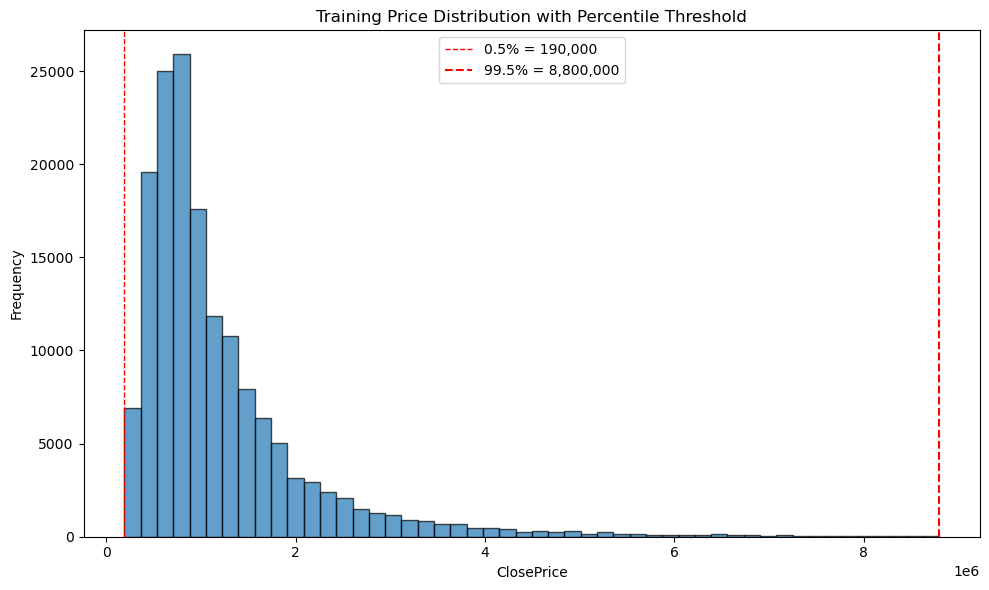

In [71]:
# Target Distribution
plt.figure(figsize=(10,6))
plt.hist(y_train, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(
    lower_threshold,
    color = "red",
    linestyle = "--",
    linewidth=1,
    label = f"0.5% = {lower_threshold:,.0f}")
plt.axvline(
    upper_threshold,
    color="red",
    linestyle="--",
    label = f"99.5% = {upper_threshold:,.0f}")
plt.xlabel("ClosePrice")
plt.ylabel("Frequency")
plt.title("Training Price Distribution with Percentile Threshold")
plt.legend()
plt.tight_layout()
plt.show()

Create a leakage-safe PostalCode and City Median Price features using 5-fold cross validation

In [72]:
# Create PostalCode/City median features using 5 folds

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_train = X_train.copy()
X_val = X_val.copy()

X_train["postalcode_median_price"] = np.nan
X_train["city_median_price"] = np.nan

global_median = y_train.median()

for train_idx, val_idx in kf.split(X_train):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_val = X_train.iloc[val_idx]

    postalcode_median = y_fold_train.groupby(X_fold_train["PostalCode"]).median()
    city_median = y_fold_train.groupby(X_fold_train["City"]).median()

    X_train.iloc[val_idx, X_train.columns.get_loc("postalcode_median_price")] = (
        X_fold_val["PostalCode"].map(postalcode_median))

    X_train.iloc[val_idx, X_train.columns.get_loc("city_median_price")] = (
        X_fold_val["City"].map(city_median))

X_train["postalcode_median_price"] = (X_train["postalcode_median_price"].fillna(global_median))
X_train["city_median_price"] = (X_train["city_median_price"].fillna(global_median))
      

Added typical price for each PostalCode and City to the validation data using the median price

In [73]:
# Create a postalcode/city median price features 

postalcode_median = y_train.groupby(X_train["PostalCode"]).median()
city_median = y_train.groupby(X_train["City"]).median()

X_val["postalcode_median_price"] = (X_val["PostalCode"].map(postalcode_median).fillna(global_median))
X_val["city_median_price"] = (X_val["City"].map(city_median).fillna(global_median))


Target encode PostalCode and City

Converted PostalCode and City into price-based numerical features using target encoding while using cross-validation to prevent data leakage.

In [74]:

X_train_encoded = X_train.copy()

for col in ["PostalCode", "City"]:
    X_train_encoded[col] = np.nan

for train_idx, val_idx in kf.split(X_train):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_val = X_train.iloc[val_idx]

    encoder = ce.TargetEncoder(
        cols = ["PostalCode", "City"],
        smoothing = 10
    )

    encoder.fit(X_fold_train, y_fold_train)

    encoded_fold = encoder.transform(X_fold_val)

    X_train_encoded.iloc[val_idx,
        X_train_encoded.columns.get_indexer(["PostalCode", "City"])
        ] = encoded_fold[["PostalCode", "City"]].values

final_encoder = ce.TargetEncoder(
    cols = ["PostalCode", "City"],
    smoothing = 10 )

final_encoder.fit(X_train, y_train)
X_val_encoded = final_encoder.transform(X_val)

X_train = X_train_encoded
X_val = X_val_encoded


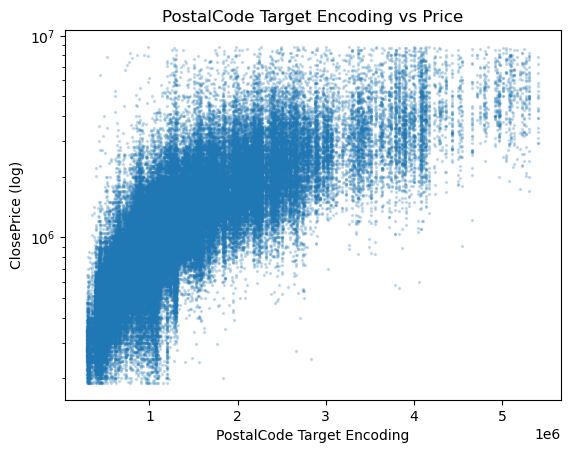

In [75]:
plt.scatter(
    X_train["PostalCode"],
    y_train, 
    alpha=0.2,
    s = 2)
plt.yscale("log")
plt.xlabel("PostalCode Target Encoding")
plt.ylabel("ClosePrice (log)")
plt.title("PostalCode Target Encoding vs Price")
plt.show()

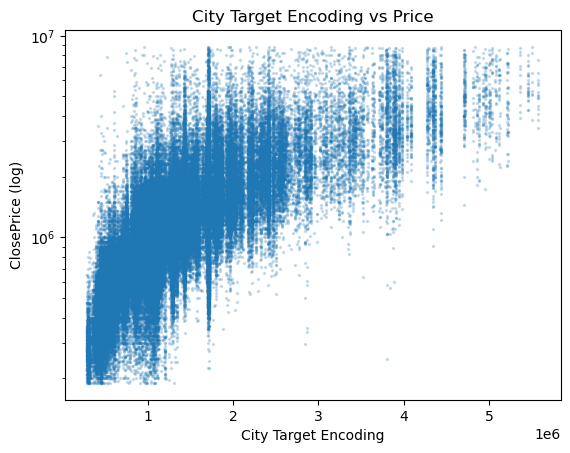

In [76]:
plt.scatter(
    X_train["City"],
    y_train, 
    alpha=0.2,
    s = 2)
plt.yscale("log")
plt.xlabel("City Target Encoding")
plt.ylabel("ClosePrice (log)")
plt.title("City Target Encoding vs Price")
plt.show()

Plots show positive relationships between 
1.  PostalCode and ClosePrice and also
2.  City and ClosePrice
indicating that location is an important predictor of property value. 

Next week will focus on evaluating linear regression model with $R^2$ and recording baseline results.